In [79]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

### Two networks interposed

- Layer 1: random network with 500 nodes and $p=0.05$. [Serves as more frequent contacts].
- Layer 2: random network with 500 nodes and $p=0.02$ (Less connectivity). [Serves as sporadic contacts].

Perform adaptive process for each network to reduce corresponding nodes. Adaptive parameters:

- Layer 1: T=14 days, $\nu=0.025$
- Layer 2: T=14 days, $\nu=0.0125$ (individuals are more sensitive).

The main difference in this example is that the adjacency matrix used to compute disease transition probabilities is the boolean sum of the two adjacency matrices for the two interposed networks.

In [146]:
dat_ = pd.read_csv('./Data/2layerexperiment.csv')
dat_['s'] = dat_['s']/500
dat_['i'] = dat_['i']/500
dat_['r'] = dat_['r']/500
dat_

,day,s,i,r,edgecount1,suscedgecount1,edgecount2,suscedgecount2
0,1,0.998,0.002,0.000,1.0,1.0,1.0,1.0
1,2,0.998,0.002,0.000,1.0,1.0,1.0,1.0
2,3,0.998,0.002,0.000,1.0,1.0,1.0,1.0
3,4,0.998,0.002,0.000,1.0,1.0,1.0,1.0
4,5,0.996,0.004,0.000,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...
195,196,0.002,0.044,0.954,1.0,1.0,1.0,1.0
196,197,0.002,0.044,0.954,1.0,1.0,1.0,1.0
197,198,0.002,0.044,0.954,1.0,1.0,1.0,1.0
198,199,0.002,0.044,0.954,1.0,1.0,1.0,1.0


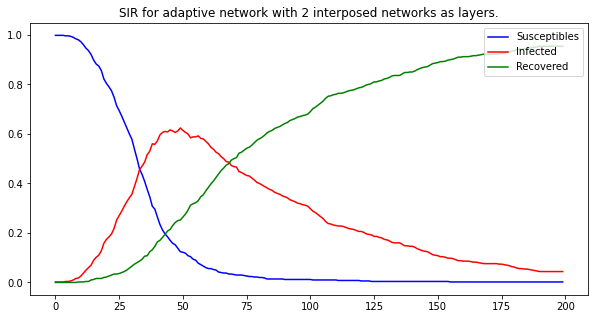

In [147]:
plt.figure(figsize=(10,5))
plt.plot(dat_['s'], '-b', label="Susceptibles")
plt.plot(dat_['i'], '-r', label="Infected")
plt.plot(dat_['r'], '-g', label="Recovered")
plt.title("SIR for adaptive network with 2 interposed networks as layers.")
plt.legend(loc="upper right")
plt.show()

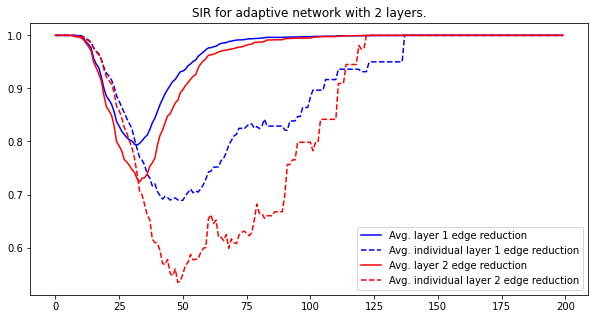

In [148]:
plt.figure(figsize=(10,5))
plt.plot(dat_['edgecount1'],'-b', label="Avg. layer 1 edge reduction")
plt.plot(dat_['suscedgecount1'], linestyle='--', color='b', label="Avg. individual layer 1 edge reduction")
plt.plot(dat_['edgecount2'],'-r', label="Avg. layer 2 edge reduction")
plt.plot(dat_['suscedgecount2'], linestyle='--', color='r', label="Avg. individual layer 2 edge reduction")
plt.title("SIR for adaptive network with 2 layers.")
plt.legend(loc="lower right")
plt.show()

We can see that contact adaptation occurs more drastically for the outer sporadic layer.

### One network for layer 1 contacts and layer 2 contacts performed sporadically within the same network

We build an underlying network. The layer 1 contacts are to be pooled from the neighbors of this network using the adaptive decision process. The layer 2 contacts are pooled from the rest of the network nodes sporadically, also using the adaptive algorithm to decide the optimal number of nodes to select for this network. So, each day, susceptible nodes have contacts with a sample of their original neighbors and a sample of other neighbors chosen randomly from the rest of the population, but the amount to choose is computed with the adaptive framework.

In [161]:
dat_ = pd.read_csv('./Data/layerexperiment.csv')
dat_['s'] = dat_['s']/500
dat_['i'] = dat_['i']/500
dat_['r'] = dat_['r']/500
dat_

,day,s,i,r,edgecount,suscedgecount
0,1,0.998,0.002,0.000,1.000000,0.945607
1,2,0.998,0.002,0.000,0.994038,0.942046
2,3,0.998,0.002,0.000,0.995032,0.941284
3,4,0.996,0.004,0.000,0.977891,0.932771
4,5,0.996,0.004,0.000,0.987828,0.937390
...,...,...,...,...,...,...
195,196,0.000,0.012,0.988,0.961620,NaN
196,197,0.000,0.010,0.990,0.964104,NaN
197,198,0.000,0.010,0.990,0.965719,NaN
198,199,0.000,0.010,0.990,0.962241,NaN


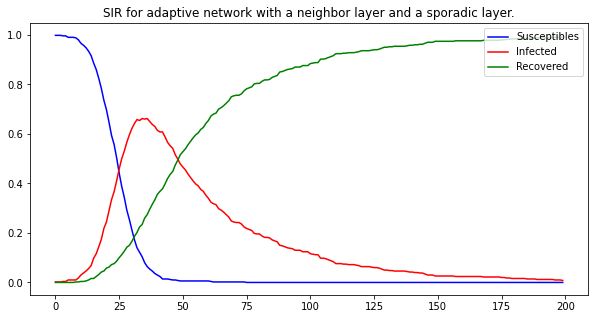

In [162]:
plt.figure(figsize=(10,5))
plt.plot(dat_['s'], '-b', label="Susceptibles")
plt.plot(dat_['i'], '-r', label="Infected")
plt.plot(dat_['r'], '-g', label="Recovered")
plt.title("SIR for adaptive network with a neighbor layer and a sporadic layer.")
plt.legend(loc="upper right")
plt.show()

In [165]:
datc_ = pd.read_csv('./Data/contactinfo.csv')
datc_ = datc_.groupby(['day'], as_index=False).agg({'L1_contacts': ['mean', 'max', 'min', 'std'],
                                                    'L2_contacts': ['mean', 'max', 'min', 'std']})
datc_.columns = datc_.columns.droplevel()
datc_.columns = ['day', 
                 'L1_mean', 'L1_max', 'L1_min', 'L1_std', 
                 'L2_mean', 'L2_max', 'L2_min', 'L2_std']

datc_['L1_mean'] = datc_['L1_mean']/np.nanmax(datc_['L1_mean'])
datc_['L2_mean'] = datc_['L2_mean']/np.nanmax(datc_['L2_mean'])
datc_

,day,L1_mean,L1_max,L1_min,L1_std,L2_mean,L2_max,L2_min,L2_std
0,0,1.000000,38,8,4.725685,0.999597,10,0,0.840450
1,1,0.996046,39,9,4.555283,0.989919,10,0,1.204367
2,2,0.996136,39,10,4.779551,0.991532,10,0,1.152284
3,3,0.984725,38,8,4.675789,0.963710,10,0,1.847492
4,4,0.990925,39,10,4.567997,0.979839,10,0,1.498697
...,...,...,...,...,...,...,...,...,...
195,195,0.946177,34,6,4.678908,0.995968,10,0,1.089943
196,196,0.949052,36,6,4.849294,0.997984,10,0,0.995984
197,197,0.951568,37,6,4.995750,0.997984,10,0,0.995984
198,198,0.945997,40,5,4.842289,0.997984,10,0,0.995984


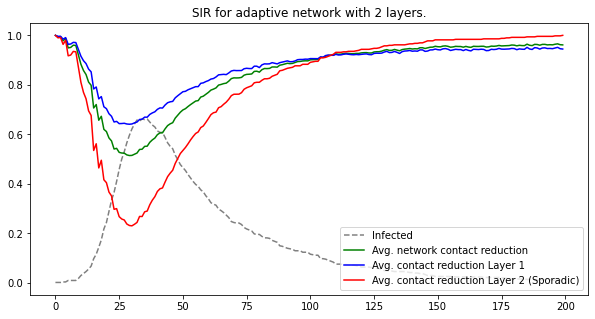

In [183]:
plt.figure(figsize=(10,5))
plt.plot(dat_['i'],'gray', linestyle='--', label="Infected")
plt.plot(dat_['edgecount'], '-g', label="Avg. network contact reduction")
plt.plot(datc_['L1_mean'], '-b', label="Avg. contact reduction Layer 1")
plt.plot(datc_['L2_mean'], 'r', label="Avg. contact reduction Layer 2 (Sporadic)")
plt.title("SIR for adaptive network with 2 layers.")
plt.legend(loc="lower right")
plt.show()

Which experiment is *better*?